## K-Nearest Neighbors (K-Vizinhos mais Próximos)

Dado um conjunto de observações

$$
V = \{(\vec{x_{i}}, y_{i})\}_{i=1}^{n}
$$
    
onde

$$
\vec{x_i} =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R^{d}} \quad
  y_i \in \mathbb{N}
$$

ou seja, $\vec{x_i}$ é um vetor de atributos e $y_i$ é um rótulo sendo, nesse caso, um valor discreto.

Vamos definir o conjunto de rótulos como sendo:

$$
C = \{ y_i \}_{i=1}^{m}, \quad m \leq n
$$

Dado um novo vetor de atributos $\vec{z}$, vamos calcular a distância Euclidiana entre $\vec{z}$ e todos os vetores de treino $\vec{x_i}$:

$$
d(\vec{z}, \vec{x_i}) = \sqrt{\sum_{k=1}^{d}(z_{k} - x_{ik})^{2}}
$$


Conseguimos assim determinar o vetor $\omega$, o vetor de distâncias de $\vec{z}$ a cada um dos $\vec{x_i}$

$$
\vec{\omega} =
\begin{bmatrix}
  d(\vec{z}, \vec{x_1}) \\ d(\vec{z}, \vec{x_2}) \\ \vdots \\ d(\vec{z}, \vec{x_n}) \in \mathbb{R^{d}}
\end{bmatrix}
$$

Ordenando $\omega$, encontramos as $k$ menores distâncias e seus respectivos índices:

$$
I_k = \operatorname{argsort}(\vec{\omega})_{1:k}
$$

Os rótulos correspondentes aos $k$ vizinhos mais próximos são então:

$$
\{y_{(1)}, y_{(2)}, \ldots, y_{(k)}\} \quad \text{onde } y_{(i)} = y_{I_k(i)}
$$


Por fim, dada a função indicadora $\mathbb{I}(\cdot)$:

$$
\mathbb{I}(A) =
\begin{cases}
1, & \text{se a condição } A \text{ é verdadeira} \\
0, & \text{caso contrário}
\end{cases}
$$


determinamos o rótulo predito $\hat{y}$ como sendo aquele que **maximiza o número de ocorrências** entre os $k$ vizinhos mais próximos:

$$
\hat{y} = \arg\max_{c \in C} \sum_{i=1}^{k} \mathbb{I}(y_{(i)} = c)
$$


## Aplicação

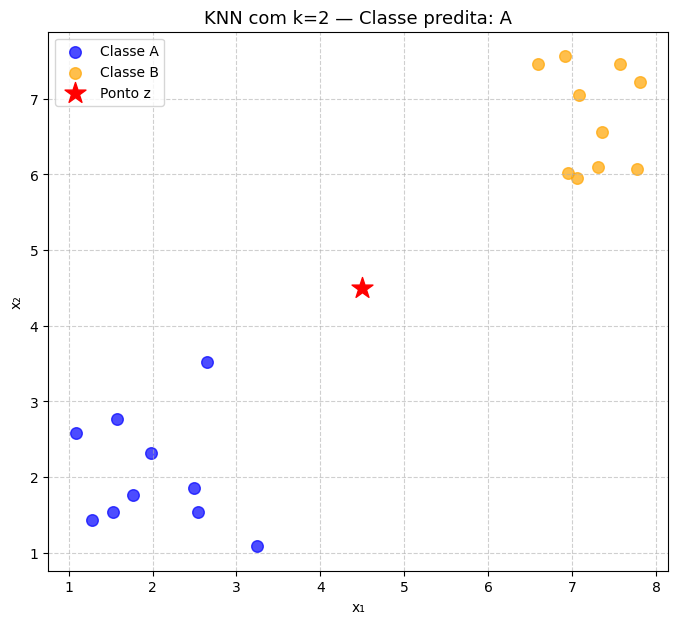

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from math import sqrt

def dist(x, z):
    return sqrt(np.sum((np.array(x) - np.array(z))**2))
\
def knn(data, labels, z, k):
    omega = np.array([dist(x_i, z) for x_i in data])
    Ik = np.argsort(omega)[:k]
    Ck = labels[Ik]
    y = Counter(Ck).most_common(1)[0][0]
    return y

A = np.array([
 [2.49671415, 1.8617357 ],
 [2.64768854, 3.52302986],
 [1.76584663, 1.76586304],
 [1.57921282, 2.76743473],
 [1.53052561, 1.54256004],
 [2.53658231, 1.53427025],
 [3.24196227, 1.08671976],
 [1.27508217, 1.43771247],
 [1.98716888, 2.31424733],
 [1.09197592, 2.5876963 ]
])

B = np.array([
 [7.35778736, 6.56078453],
 [7.08305124, 7.05380205],
 [7.054256  , 5.95366171],
 [6.95342823, 6.02419623],
 [7.80867198, 7.22745993],
 [6.91877001, 7.56228753],
 [7.31424733, 6.09197592],
 [6.5876963 , 7.46564877],
 [7.7742237 , 6.0675282 ],
 [7.57525181, 7.45561728]
])

data = np.vstack((A, B))
labels = np.array(['A'] * len(A) + ['B'] * len(B))

z = np.array([4.5, 4.5])
k = 2

label_pred = knn(data, labels, z, k)

plt.figure(figsize=(8, 7))

for classe, cor in zip(np.unique(labels), ['blue', 'orange']):
    pontos = data[labels == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Classe {classe}', color=cor, s=70, alpha=0.7)

plt.scatter(z[0], z[1], color='red', marker='*', s=250, label=f'Ponto z')

plt.title(f'KNN com k={k} — Classe predita: {label_pred}', fontsize=13)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
